In [1]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"

import sphWarpCore as sph
from sphWarpCore.type_config import *

print(get_type_config()) # confirms active settings

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
from compressibleSPH.enumTypes import *

nx = 128
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme


L = 2
dim = 2
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min = torch.tensor([0, 0], device = device, dtype = dtype)
domain.max = torch.tensor([1, 1], device = device, dtype = dtype)

config = SimulationConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
    verletScale=1.0
)
config.nx = nx
config.dx = 1 / config.nx

# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('MonaghanCompressibleSPH')
# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')
SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')

schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = leftState.rho
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
schemeConfig.viscositySwitchParams.correctVelocityGradient = True
schemeConfig.adaptiveSupportCorrections = False

display(schemeConfig)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True

# compressibleSPHConfig = CompressibleSPHConfig(
#     gamma = gamma,
#     rho0 = leftState.rho,
#     diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

schemeConfig.crkViscosityParams.enableCRKLimiter = False


CRKSPHConfig(gamma=1.6666666666666667, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=False, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=2,
	Cu_l=1,
	Cu_q=2,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.CullenHopkins: 3>, limitXi=True, correctVelocityGradient=True, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', energyScheme=<EnergyScheme.CRK: 5>, crkViscosityParams=CRKViscosity(
	eta_fold=float32(0),
	eta_crit=float32(0),
	enableCRKLimiter=bool(False),
	enableVanLeerLimiter=bool(False),
	forceVanLeerOff=bool(False),
	forceVanLeerOn=bool(False),
))

In [3]:
# compSystem = buildSedov(
#     SimulationSystem, SimulationState, 
#     config = config,
#     nx = nx, dim = dim, domainExtent = L, 
#     periodicDomain = True, 
#     rho0 = rho0, E0 = E0, 
#     initialization = 'quadrant', 
#     gamma = gamma, kernel = config.kernel, 
#     targetNeighbors = config.targetNeighbors, 
#     dtype = config.dtype, device = config.device)

In [4]:


particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)
# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * schemeConfig.rho0)


print(f"Sampled {particles_.positions.shape[0]} particles.")
print(f' Support: Min: {particles_.supports.min().item()}, Max: {particles_.supports.max().item()}, Mean: {particles_.supports.mean().item()}')

particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


densities = warpOperation(
    particles, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)
particles.densities = densities

compressibleSPHConfig = CompressibleSPHConfig(
    adaptiveSupportIterations=16,
    adaptiveSupportThreshold=1e-3,
    adaptiveSupportScheme=AdaptiveSupportScheme.Monaghan,
)

from compressibleSPH.modules import *

# wrappedKernel = warpKernelToDiffSPHKernel(kernel)
# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)
# particleState.supports = h_optimal

# particles.densities = rho_optimal
# particles.supports = h_optimal

print(f' Support After Optimization: Min: {particles.supports.min().item()}, Max: {particles.supports.max().item()}, Mean: {particles.supports.mean().item()}')

P_initial = torch.zeros_like(particles.densities)
u = 1 / (gamma - 1) * (P_initial / rho_optimal)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

simulationState_ = SimulationState(
    positions = particles.positions,
    supports = particles.supports,
    masses = particles.masses,
    densities = particles.densities,        
    velocities = torch.zeros_like(particles.positions),

    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles.densities),
    alpha0s = torch.ones_like(particles.densities),
    divergence=torch.zeros_like(particles.densities),
)
    


adjacency = buildVerletList(simulationState_, 
                            domain = config.domain,
                            verletScale = 2**(1/config.dim), supportMode = config.supportMode)

compressibleSystem = SimulationSystem(
    state=simulationState_, 
    adjacency = adjacency, 
    domain = config.domain)


Sampled 16384 particles.
 Support: Min: 0.03125, Max: 0.03125, Mean: 0.03125
Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 4.51 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 4082809 load on device 'cuda:0' took 6.99 ms  (cached)
Module sphWarpCore.operations.wp_density 4d00ae0 load on device 'cuda:0' took 2.89 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega fc0d31f load on device 'cuda:0' took 8.31 ms  (cached)
 Support After Optimization: Min: 0.03124995343387127, Max: 0.031249957159161568, Mean: 0.03124995343387127


In [5]:
particles = compressibleSystem.state

In [6]:
rho1 = 1.0
rho2 = 2.0
rhom = (rho1 - rho2) / 2
v1 = 0.5
v2 = -0.5
vm = (v1 - v2) / 2
delta = 0.025
delta_y = 0.01
lamda = 1/2

import numpy as np
v_y = delta_y * torch.sin(2 * np.pi * particles.positions[:, 0] / lamda)

In [7]:
import math

freq = 4.0
w0 = 0.1
sigma = 0.05/math.sqrt(2.0)

def vy(ri):
        thpt = 1.0/(2.0*sigma*sigma)
        return (w0*torch.sin(freq*np.pi*ri[:, 0]) *
                (torch.exp(-((ri[:, 1] - 0.25)**2 * thpt)) +
                 torch.exp(-((ri[:, 1] - 0.75)**2 * thpt))))*torch.abs(0.5 - ri[:, 1])

v_y = vy(particles.positions)

In [8]:
region1 = torch.logical_and(particles.positions[:, 1] >= 0, particles.positions[:, 1] < 1/4)
region2 = torch.logical_and(particles.positions[:, 1] >= 1/4, particles.positions[:, 1] < 1/2)
region3 = torch.logical_and(particles.positions[:, 1] >= 1/2, particles.positions[:, 1] < 3/4)
region4 = torch.logical_and(particles.positions[:, 1] >= 3/4, particles.positions[:, 1] <= 1)

rho = torch.zeros_like(particles.densities)

rho[region1] = rho1# - rhom * torch.exp((particles.positions[region1, 1] - 1/4) / delta)
rho[region2] = rho2# + rhom * torch.exp((1/4 - particles.positions[region2, 1]) / delta)
rho[region3] = rho2# + rhom * torch.exp((particles.positions[region3, 1] - 3/4) / delta)
rho[region4] = rho1# - rhom * torch.exp((3/4 - particles.positions[region4, 1]) / delta)

print(f'rho1 = {rho1}, rho2 = {rho2}, rhom = {rhom}')
print(f'rho min = {rho.min()}, rho max = {rho.max()}, mean = {rho.mean()}')


v_x = torch.zeros_like(particles.positions[:, 0])
v_x[region1] = v1 - vm * torch.exp((particles.positions[region1, 1] - 1/4) / delta)
v_x[region2] = v2 + vm * torch.exp((1/4 - particles.positions[region2, 1]) / delta)
v_x[region3] = v2 + vm * torch.exp((particles.positions[region3, 1] - 3/4) / delta)
v_x[region4] = v1 - vm * torch.exp((3/4 - particles.positions[region4, 1]) / delta)

print(f'v1 = {v1}, v2 = {v2}, vm = {vm}')
print(f'v min = {v_x.min()}, v max = {v_x.max()}, mean = {v_x.mean()}')

v_initial = torch.stack([v_x, v_y], dim = 1)

rho1 = 1.0, rho2 = 2.0, rhom = -0.5
rho min = 1.0, rho max = 2.0, mean = 1.5
v1 = 0.5, v2 = -0.5, vm = 0.5
v min = -0.49997347593307495, v max = 0.49997347593307495, mean = 0.0


In [9]:
particlesInRegion1 = region1.sum().item()
particlesInRegion2 = region2.sum().item()
particlesInRegion3 = region3.sum().item()
particlesInRegion4 = region4.sum().item()

print(f'Particles in region 1: {particlesInRegion1}')
print(f'Particles in region 2: {particlesInRegion2}')
print(f'Particles in region 3: {particlesInRegion3}')
print(f'Particles in region 4: {particlesInRegion4}')

print(f'Particles in total: {particles.positions.shape[0]}')
print(f'Particles in all regions: {particlesInRegion1 + particlesInRegion2 + particlesInRegion3 + particlesInRegion4}')

total = region1.to(torch.int32) + region2.to(torch.int32) + region3.to(torch.int32) + region4.to(torch.int32)
print(f'Total particles in all regions: {total.sum().item()}, min: {total.min().item()}, max: {total.max().item()}')

Particles in region 1: 4096
Particles in region 2: 4096
Particles in region 3: 4096
Particles in region 4: 4096
Particles in total: 16384
Particles in all regions: 16384
Total particles in all regions: 16384, min: 1, max: 1


In [10]:
Pinitial = torch.ones_like(rho) * 2.5


A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = rho, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(v_initial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

particles.internalEnergies = u_
particles.totalEnergies = totalEnergy
particles.pressures = P_
particles.soundspeeds = c_s
particles.velocities = v_initial
particles.densities = rho
particles.masses = config.dx**config.dim * rho

compressibleSystem = SimulationSystem(
    state=particles, 
    adjacency = adjacency, 
    domain = config.domain)

In [11]:

# rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)

# compressibleSystem.state.supports = h_optimal


In [12]:

adjacency = buildVerletList(
    compressibleSystem.state, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, densities, crkState = computeCRKFactors(compressibleSystem.state, config.domain, config.kernel, adjacency = adjacency)

Module sphWarpCore.crk.crk_volume bbb56f1 load on device 'cuda:0' took 2.24 ms  (cached)
Module sphWarpCore.crk.crk_moments 3a30c05 load on device 'cuda:0' took 4.91 ms  (cached)
Module sphWarpCore.crk.crk_density bc94b18 load on device 'cuda:0' took 1.97 ms  (cached)


In [13]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 12.5
plotter = visualize(
    particleState = compressibleSystem.state,
    domain = config.domain,
    quantities = {
        "A": densities,
        "B": h_optimal,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Densities",
            # mapping = Mapping.L2,
            # plottingOperation = OperationProperties(
            #     kernel = config.kernel,
            #     operation = WarpOperation.Curl,
            #     supportMode = SupportScheme.Gather,
            #     gradientMode = config.gradientMode,
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 256,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Support Radius",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=0.95,
            # vMax=2.05
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [14]:
from warpPlot import *

In [15]:
# fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
# plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
# plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
# plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
# plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
# fig.tight_layout()

In [16]:
KE = (compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**2 / 2).sum()
IE = (compressibleSystem.state.masses * compressibleSystem.state.internalEnergies).sum()
TE = (compressibleSystem.state.masses * (compressibleSystem.state.internalEnergies + torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**
2)).sum()
print(f"Initial KE: {KE}, IE: {IE}, TE: {TE}, TE+PE: {TE}")

nonzeroEnergyMask = compressibleSystem.state.internalEnergies > 1e-8
print(f"Nonzero internal energy particles: {nonzeroEnergyMask.sum()} / {compressibleSystem.state.internalEnergies.shape[0]}")

Initial KE: 0.15940606594085693, IE: 3.75, TE: 4.068811893463135, TE+PE: 4.068811893463135
Nonzero internal energy particles: 16384 / 16384


In [17]:
from compressibleSPH.schemes.compSPH import compSPH_step
from compressibleSPH.modules.timestep.compressible import computeTimestep
config.dt = computeTimestep(compressibleSystem, config, schemeConfig, dt = config.dt) * 2/3
print(f"Initial timestep: {config.dt}")

Initial timestep: 0.000778556801378727


In [18]:
runningState = compressibleSystem.initializeNewState()

In [19]:
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.diffusionParams.C_q = 1.0



In [20]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 12.5
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.internalEnergies,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "internal energy",
            # mapping = Mapping.L2,
            # plottingOperation = OperationProperties(
            #     kernel = config.kernel,
            #     operation = WarpOperation.Curl,
            #     supportMode = SupportScheme.Gather,
            #     gradientMode = config.gradientMode,
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 256,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "density",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=0.95,
            # vMax=2.05
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [23]:
# schemeConfig.diffusionParams.C_l = 0.0
schemeConfig.diffusionParams.C_q = 1.0
schemeConfig.crkViscosityParams.eta_fold = 0.2
schemeConfig.crkViscosityParams.eta_crit = 1./4. #* 2.121321
schemeConfig.crkViscosityParams.forceVanLeerOff = False
schemeConfig.crkViscosityParams.enableCRKLimiter = True
schemeConfig.crkViscosityParams.enableVanLeerLimiter = True

display(schemeConfig.crkViscosityParams)

CRKViscosity(
	eta_fold=0.2,
	eta_crit=0.25,
	enableCRKLimiter=True,
	enableVanLeerLimiter=True,
	forceVanLeerOff=False,
	forceVanLeerOn=bool(False),
)

In [ ]:
os.makedirs('images/kevinHH2', exist_ok = True)

t_limit = 4.0
# config.dt = 1e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)


print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
 
trajectory = []
runningState = compressibleSystem.initializeNewState()
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    # print(f"Step {i+1}/{nSteps}, time: {runningState.t:.4f}")
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,
        config = config,
        compParams = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    elapsed_time_ms = begin.elapsed_time(end)

    runningState = result.state
    priorStep = result.stages[-1]

    kineticEnergy_ = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy_ = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy_ + thermalEnergy_

    tq.set_description(f"t: {runningState.t:.4f}, KE: {kineticEnergy_:.4f}, TE: {thermalEnergy_:.4f}, TE+KE: {totalEnergy:.4f}")
        
    trajectory.append((
        i,
        runningState.t,
        elapsed_time_ms,
        kineticEnergy_.cpu().item(),
        thermalEnergy_.cpu().item(),
        totalEnergy.cpu().item(),
    ))
    if i % 10 == 0 or i == nSteps - 1:
        plotter.updateQuantities(
            {
                "A": runningState.state.internalEnergies,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'images/kevinHH2/frame_{i:05d}.png', dpi = 300)
        # for ax in axis.flatten():
        #     ax.clear()
        # plotSod_(fig, axis, runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = True, t_ = runningState.t)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
    # print(f' Supports: Min: {runningState.state.supports.min().item()}, Max: {runningState.state.supports.max().item()}, Mean: {runningState.state.supports.mean().item()}')

Running with dt: 0.000778556801378727, which gives nSteps: 2568


  0%|          | 0/2568 [00:00<?, ?it/s]

In [ ]:
ffmpeg -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4
fmpeg -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png
ffmpeg -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif

In [45]:
cState = runningState.initializeNewState()
currentState = cState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, currentState.densities, crkState = computeCRKFactors(currentState, config.domain, config.kernel, adjacency = adjacency)


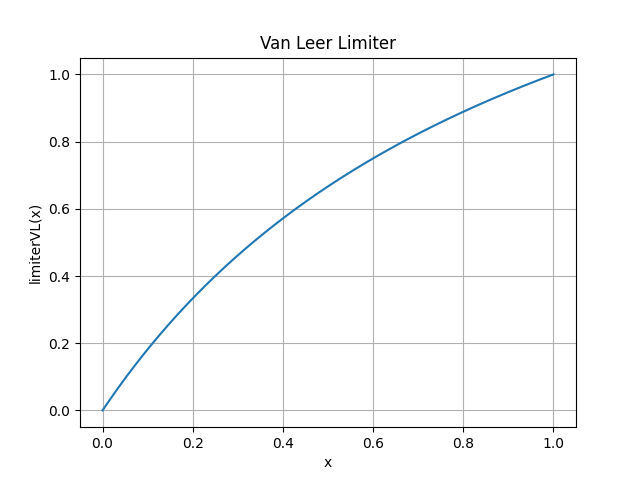

In [46]:
def limiterVL(x):
    # if x <= 0.0:
        # return 0.0
    # x = wp.min(x, scalar_t(1.0e6))
    # vL = 2.0 / (1.0 + x)
    # return x * vL*vL

    return (x + torch.abs(x)) / (1.0 + torch.abs(x))

xx = torch.linspace(0, 1, 1000)
yy = limiterVL(xx)

fig, ax = plt.subplots()
ax.plot(xx.cpu(), yy.cpu())
ax.set_title("Van Leer Limiter")
ax.set_xlabel("x")
ax.set_ylabel("limiterVL(x)")
plt.grid()


In [47]:
velocityGradient = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    # queryVolumes = apparentVolume,
    # crkState= crkState,
)

velocityGradientCRK = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    queryVolumes = apparentVolume,
    crkState= crkState,
)

In [48]:
trace = torch.einsum('...ii', velocityGradient)

traces = torch.eye(velocityGradient.shape[1], device=velocityGradient.device) * trace.view(-1, 1, 1) / velocityGradient.shape[1]

Shear = (velocityGradient + velocityGradient.transpose(1,2))/2 - traces
Rotation = (velocityGradient - velocityGradient.transpose(1,2)) / 2

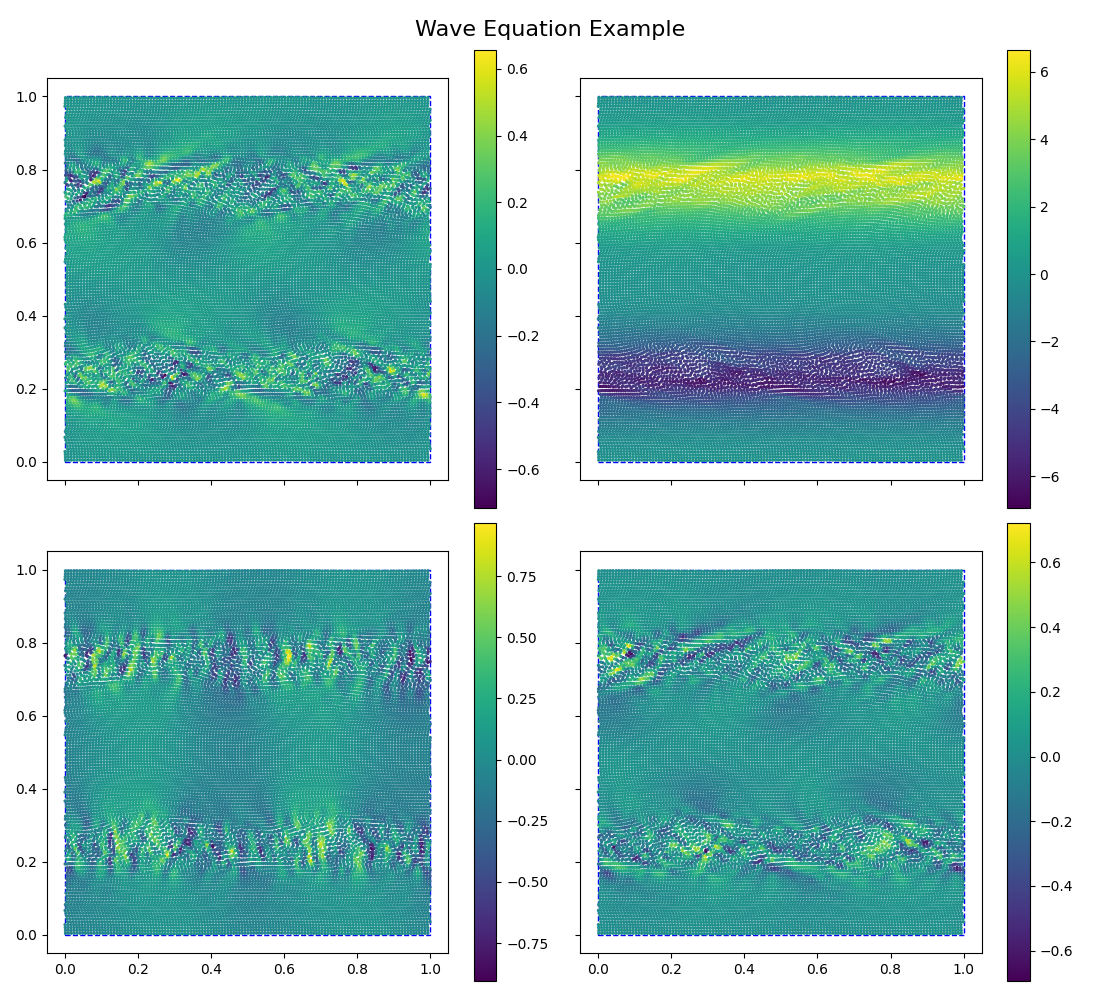

In [49]:
matrix = velocityGradient# - velocityGradientCRK
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 2
plotter = visualize(
    particleState = currentState,
    domain = config.domain,
    quantities = {
        "A": matrix[:,0,0],
        "B": matrix[:,0,1],
        "C": matrix[:,1,0],
        "D": matrix[:,1,1],
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "C": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "D": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = '''AB
    CD''',
    figsize= (11,10),
    # backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

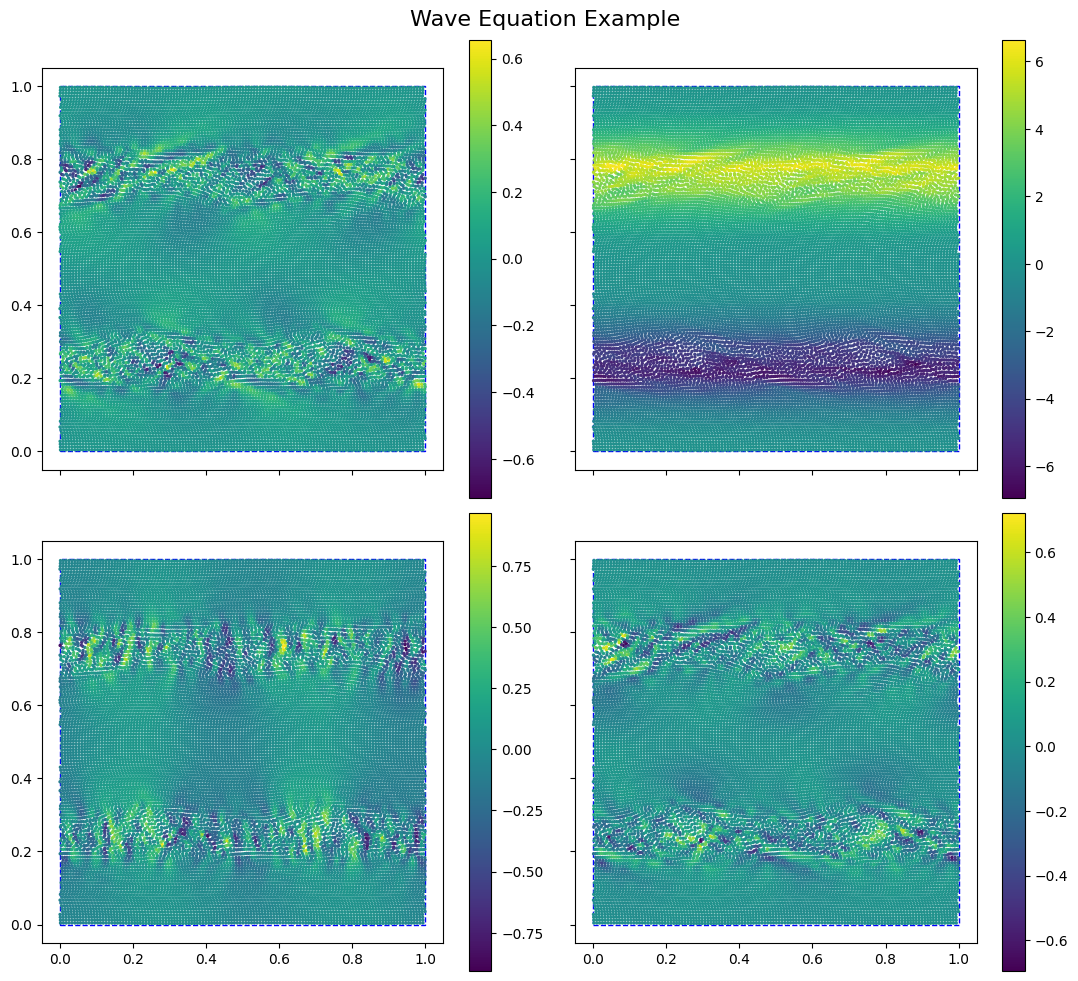

In [50]:
display(plotter.fig)